<a href="https://colab.research.google.com/github/HY-BME/bme_test_files/blob/%EB%B0%94%EC%9D%B4%EC%98%A4%EA%B3%B5%ED%95%99%EC%98%A4%ED%94%88%EC%86%8C%EC%8A%A4%EA%B8%B0%EC%88%A0/ML_diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [64]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

#분류(Classification) 모델 형성과 특성 중요도 파악 필요. 교차검증은 RMSE가 아닌 정확도 검사로 진행

df = pd.read_csv('/content/sample_data/diabetes.csv')

# # 대상 열 지정
# outliers = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# #SkinThickness, Insulin 는 NaN으로 치환하지 않는다
# df[outliers] = df[outliers].replace(0, np.nan)
# df[outliers] = df[outliers].fillna(df[outliers].mean())

# Define features (X) and target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# 0.2 = 80% train set, 20% test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set shape: {X_train.shape}')
print(f'Testing set shape: {X_test.shape}')

df.head()


Training set shape: (614, 8)
Testing set shape: (154, 8)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


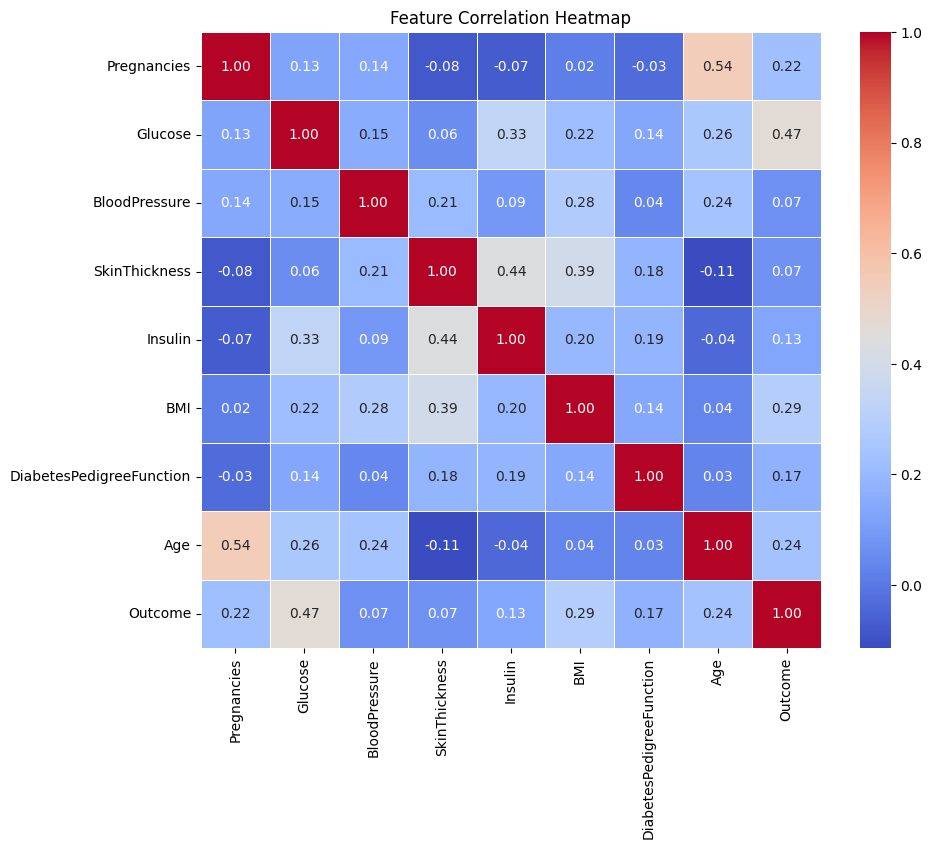

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 상관계수 행렬 계산
correlation_matrix = df.corr(numeric_only=True)

# 2. 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

# Outcome(타겟)과의 상관관계만 따로 보기
print(correlation_matrix['Outcome'].sort_values(ascending=False))

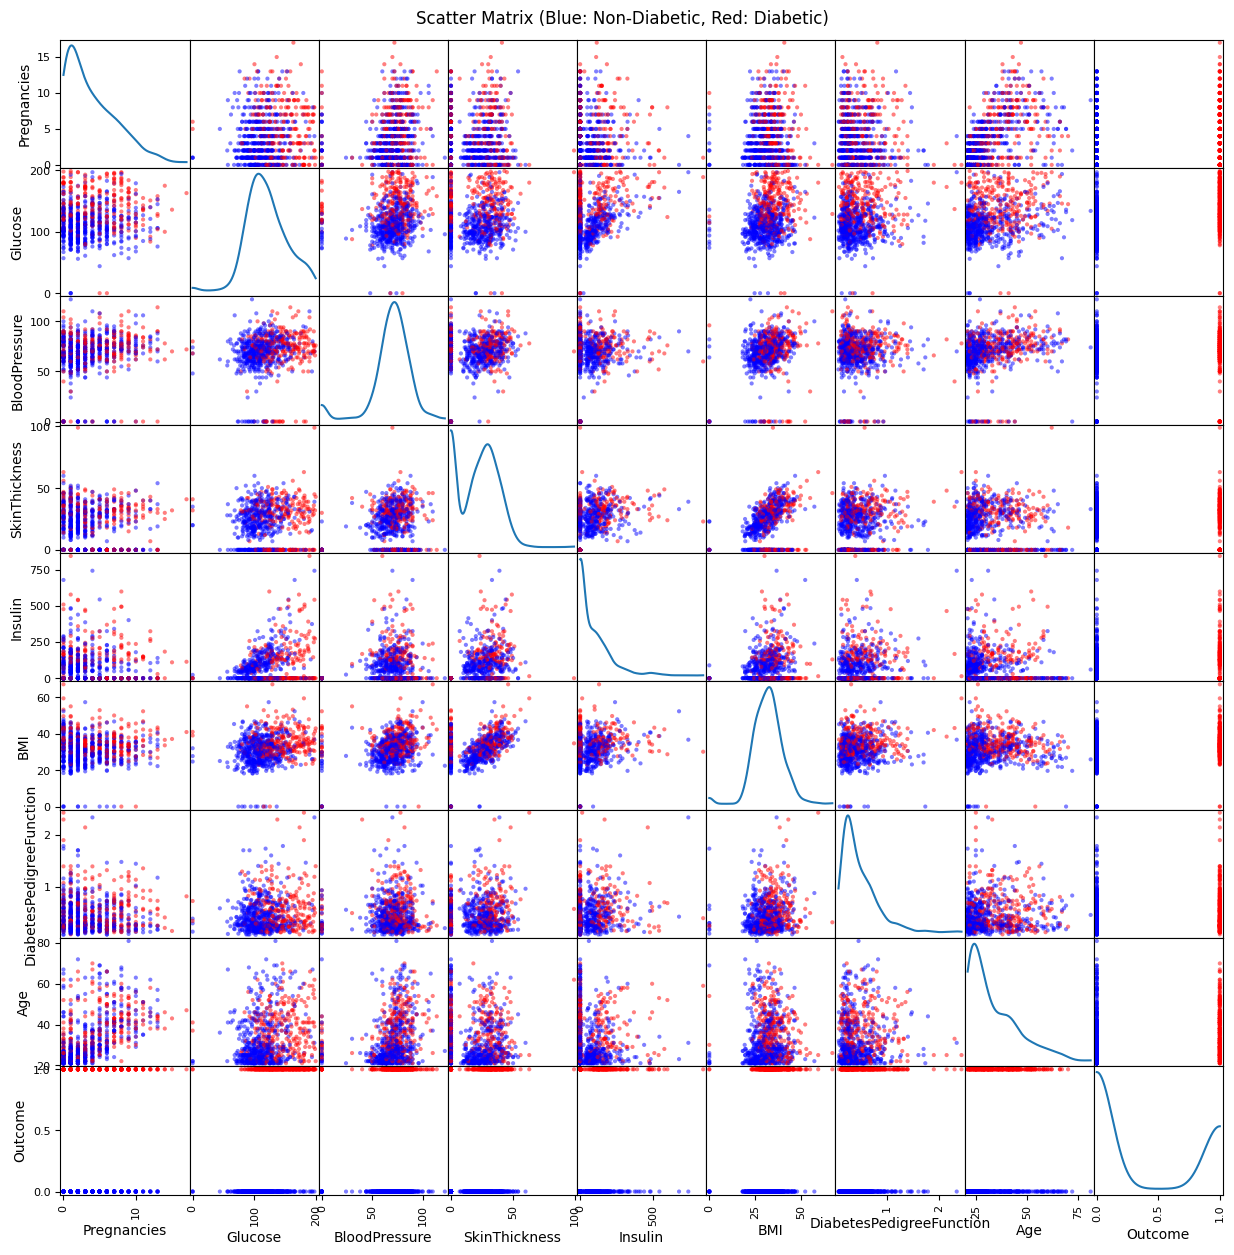

In [66]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

colors = df['Outcome'].map({0: 'blue', 1: 'red'})

scatter_matrix(df, alpha=0.5, figsize=(15, 15), diagonal='kde', c=colors)
plt.suptitle('Scatter Matrix (Blue: Non-Diabetic, Red: Diabetic)', y=0.9)
plt.show()

In [67]:
# 새로운 특성 생성: Glucose와 BMI의 곱 : 대사
df['Metabolic'] = df['Glucose'] * df['BMI']

# 새로운 특성 생성: Insulin / (Glucose+1) : 인슐린 저항성 근사치
df['InsulinResistance'] = df['Insulin'] / (df['Glucose'] + 1)

new_corr = df[['Glucose', 'BMI', 'Metabolic', 'InsulinResistance', 'Outcome']].corr()
display(new_corr)
df.head()

,Glucose,BMI,Metabolic,InsulinResistance,Outcome
Glucose,1.000000,0.221071,0.803245,0.035540,0.466581
BMI,0.221071,1.000000,0.740164,0.118492,0.292695
Metabolic,0.803245,0.740164,1.000000,0.103558,0.490262
InsulinResistance,0.035540,0.118492,0.103558,1.000000,0.022875
Outcome,0.466581,0.292695,0.490262,0.022875,1.000000


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Metabolic,InsulinResistance
0,6,148,72,35,0,33.6,0.627,50,1,4972.8,0.000000
1,1,85,66,29,0,26.6,0.351,31,0,2261.0,0.000000
2,8,183,64,0,0,23.3,0.672,32,1,4263.9,0.000000
3,1,89,66,23,94,28.1,0.167,21,0,2500.9,1.044444
4,0,137,40,35,168,43.1,2.288,33,1,5904.7,1.217391


In [68]:
# 원본 데이터셋 보호를 위해 Train set의 복사본 생성
X_train_copy = X_train.copy()
y_train_copy = y_train.copy()

In [69]:
from sklearn.impute import KNNImputer
import numpy as np

#결측치, 이상치 제거
risk_factors = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# 2. 0을 NaN으로 변환 (복사본 사용)
X_train_imputed = X_train_copy.copy()
X_test_imputed = X_test.copy()

X_train_imputed[risk_factors] = X_train_imputed[risk_factors].replace(0, np.nan)
X_test_imputed[risk_factors] = X_test_imputed[risk_factors].replace(0, np.nan)

imputer = KNNImputer(n_neighbors=5)

# 4. Train 데이터로 학습 및 변환, Test 데이터는 Train 기준으로 변환
X_train_imputed[risk_factors] = imputer.fit_transform(X_train_imputed[risk_factors])
X_test_imputed[risk_factors] = imputer.transform(X_test_imputed[risk_factors])

display(X_train_imputed.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
353,1,90.0,62.0,12.0,43.0,27.2,0.580,24
711,5,126.0,78.0,27.0,22.0,29.6,0.439,40
373,2,105.0,58.0,40.0,94.0,34.9,0.225,25
46,1,146.0,56.0,31.8,142.6,29.7,0.564,29
682,0,95.0,64.0,39.0,105.0,44.6,0.366,22


In [70]:
from sklearn.preprocessing import StandardScaler

#StandardScaler 스케일링 진행
scaler = StandardScaler()

X_train_imputed[risk_factors] = scaler.fit_transform(X_train_imputed[risk_factors])
X_test_imputed[risk_factors] = scaler.transform(X_test_imputed[risk_factors])

X_train_imputed[risk_factors].head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI
353,-1.059378,-0.826179,-1.768697,-1.122856,-0.770239
711,0.140705,0.473315,-0.196029,-1.353843,-0.418795
373,-0.559344,-1.151052,1.166951,-0.561886,0.357311
46,0.807417,-1.313489,0.307225,-0.027316,-0.404151
682,-0.892700,-0.663742,1.062106,-0.440893,1.777732


In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

#모델학습

# 1. LogisticRegression
lg_model = LogisticRegression(max_iter=1000, random_state=42)
lg_model.fit(X_train_imputed, y_train_copy)
lg_train_pred = lg_model.predict(X_train_imputed) #Train set
lg_test_pred = lg_model.predict(X_test_imputed) #Test set

# 2. DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_imputed, y_train_copy)
dt_train_pred = dt_model.predict(X_train_imputed)
dt_test_pred = dt_model.predict(X_test_imputed)

# 3. RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_imputed, y_train_copy)
rf_train_pred = rf_model.predict(X_train_imputed)
rf_test_pred = rf_model.predict(X_test_imputed)

#-------------- Train Set 성능 평가 ------------------------#
print("Train Set Evaluation")
print("\n--- Logistic Regression ---")
print(f"Train Accuracy: {accuracy_score(y_train_copy, lg_train_pred):.4f}")
print("Train Confusion Matrix:")
print(confusion_matrix(y_train_copy, lg_train_pred))

print("\n--- Decision Tree ---")
print(f"Train Accuracy: {accuracy_score(y_train_copy, dt_train_pred):.4f}")
print("Train Confusion Matrix:")
print(confusion_matrix(y_train_copy, dt_train_pred))

print("\n--- Random Forest ---")
print(f"Train Accuracy: {accuracy_score(y_train_copy, rf_train_pred):.4f}")
print("Train Confusion Matrix:")
print(confusion_matrix(y_train_copy, rf_train_pred))


#-------------- Test Set 성능 평가 ------------------------#
print("\n\n\nTest Set Evaluation")
print(f"\n--- Logistic Regression ---")
print(f"Test Accuracy: {accuracy_score(y_test, lg_test_pred):.4f}")
print("Test Confusion Matrix:")
print(confusion_matrix(y_test, lg_test_pred))

print("\n--- Decision Tree ---")
print(f"Test Accuracy: {accuracy_score(y_test, dt_test_pred):.4f}")
print("Test Confusion Matrix:")
print(confusion_matrix(y_test, dt_test_pred))

print("\n--- Random Forest ---")
print(f"Test Accuracy: {accuracy_score(y_test, rf_test_pred):.4f}")
print("Test Confusion Matrix:")
print(confusion_matrix(y_test, rf_test_pred))

Train Set Evaluation

--- Logistic Regression ---
Train Accuracy: 0.7980
Train Confusion Matrix:
[[362  38]
 [ 86 128]]

--- Decision Tree ---
Train Accuracy: 1.0000
Train Confusion Matrix:
[[400   0]
 [  0 214]]

--- Random Forest ---
Train Accuracy: 1.0000
Train Confusion Matrix:
[[400   0]
 [  0 214]]



Test Set Evaluation

--- Logistic Regression ---
Test Accuracy: 0.6948
Test Confusion Matrix:
[[80 20]
 [27 27]]

--- Decision Tree ---
Test Accuracy: 0.6688
Test Confusion Matrix:
[[80 20]
 [31 23]]

--- Random Forest ---
Test Accuracy: 0.7338
Test Confusion Matrix:
[[83 17]
 [24 30]]


In [72]:
#교차 검증
from sklearn.model_selection import StratifiedKFold, cross_val_score

# K Fold 교차검증(Cross Validation) 설정 //분류 모델 : StratifiedKFold
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression
lg_cv_scores = cross_val_score(lg_model, X_train_imputed, y_train_copy, cv=kfold, scoring='accuracy')
print("선형회귀 모델 교차검증 : ", lg_cv_scores)
print("선형회귀 모델 교차검증 평균 :", lg_cv_scores.mean())

# Decision Tree
dt_cv_scores = cross_val_score(dt_model, X_train_imputed, y_train_copy, cv=kfold, scoring='accuracy')
print("결정트리 모델 교차검증: ", dt_cv_scores)
print("결정트리 모델 교차검증 평균 : ", dt_cv_scores.mean())

# Random Forest
rf_cv_scores = cross_val_score(rf_model, X_train_imputed, y_train_copy, cv=kfold, scoring='accuracy')
print("랜덤포레스트 모델 교차검증 : ", rf_cv_scores)
print("랜덤포레스트 모델 교차검증 평균: ", rf_cv_scores.mean())

선형회귀 모델 교차검증 :  [0.80487805 0.79674797 0.82113821 0.78861789 0.76229508]
선형회귀 모델 교차검증 평균 : 0.7947354391576702
결정트리 모델 교차검증:  [0.69105691 0.57723577 0.69105691 0.69918699 0.66393443]
결정트리 모델 교차검증 평균 :  0.6644942023190724
랜덤포레스트 모델 교차검증 :  [0.79674797 0.77235772 0.82113821 0.76422764 0.76229508]
랜덤포레스트 모델 교차검증 평균:  0.783353325336532


In [73]:
from sklearn.model_selection import GridSearchCV

print("\n\n --------------- LogisticRegression Model Grid Search ---------------- \n\n")

# 선형회귀모델 Grid Search 진행
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

grid_search = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_grid, cv=kfold, scoring='accuracy')

# Train set 학습
grid_search.fit(X_train_imputed, y_train_copy)

print("Train set LogisticRegression Parameters: ", grid_search.best_params_)
print("Train set LogisticRegression CV Score:", grid_search.best_score_)

# Testset 평가
best_lg_model = grid_search.best_estimator_
test_acc = best_lg_model.score(X_test_imputed, y_test)
print("LogisticRegression Test Accuracy: ", test_acc)

print("\n\n --------------- RandomForest Model Grid Search ---------------- \n\n")

# Random Forest 하이퍼파라미터 그리드 설정 Grid Search 진행
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# GridSearchCV 설정
rf_grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=kfold,
    scoring='accuracy',
    n_jobs=-1
)

# Train set 학습
rf_grid_search.fit(X_train_imputed, y_train_copy)

print("Train set RandomForest Parameters: ", rf_grid_search.best_params_)
print("Train set RandomForest CV Score: ", rf_grid_search.best_score_)

# Testset 평가
best_rf_model = rf_grid_search.best_estimator_
rf_test_acc = best_rf_model.score(X_test_imputed, y_test)
print(f"RandomForest Test Accuracy: ", rf_test_acc)



 --------------- LogisticRegression Model Grid Search ---------------- 


Train set LogisticRegression Parameters:  {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Train set LogisticRegression CV Score: 0.7947487671598028
LogisticRegression Test Accuracy:  0.6948051948051948


 --------------- RandomForest Model Grid Search ---------------- 


Train set RandomForest Parameters:  {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Train set RandomForest CV Score:  0.783353325336532
RandomForest Test Accuracy:  0.7337662337662337


In [74]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Logistic Regression Random Search
lg_rand_grid = {
    'C': uniform(0.01, 100),
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

lg_random_search = RandomizedSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_distributions=lg_rand_grid,
    n_iter=20,
    cv=kfold,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

lg_random_search.fit(X_train_imputed, y_train_copy)
print("--- Train set Logistic Regression Random Search ---")
print(f"Best Parameters: {lg_random_search.best_params_}")
print(f"Best CV Score: {lg_random_search.best_score_:.4f}")

# Random Forest Random Search
rf_rand_grid = {
    'n_estimators': randint(100, 500),
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'bootstrap': [True, False]
}

rf_random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_rand_grid,
    n_iter=20,
    cv=kfold,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(X_train_imputed, y_train_copy)
print("\n--- Train set Random Forest Random Search ---")
print("Best Parameters: ", rf_random_search.best_params_)
print("Best CV Score : ", rf_random_search.best_score_)

--- Train set Logistic Regression Random Search ---
Best Parameters: {'C': np.float64(37.464011884736244), 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV Score: 0.7947

--- Train set Random Forest Random Search ---
Best Parameters:  {'bootstrap': True, 'max_depth': 40, 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 108}
Best CV Score :  0.7849526855924297


In [75]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Logistic Regression Random Search (with Feature Engineering)
lg_rand_grid_fe = {
    'C': uniform(0.01, 100),
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

lg_random_search_fe = RandomizedSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_distributions=lg_rand_grid_fe,
    n_iter=20,
    cv=kfold,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

lg_random_search_fe.fit(X_train_imputed, y_train_copy)
best_lg_fe = lg_random_search_fe.best_estimator_
lg_final_test_acc = best_lg_fe.score(X_test_imputed, y_test)

# 2. Random Forest Random Search (with Feature Engineering)
rf_rand_grid_fe = {
    'n_estimators': randint(100, 500),
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'bootstrap': [True, False]
}

rf_random_search_fe = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_rand_grid_fe,
    n_iter=20,
    cv=kfold,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

rf_random_search_fe.fit(X_train_imputed, y_train_copy)
best_rf_fe = rf_random_search_fe.best_estimator_
rf_final_test_acc = best_rf_fe.score(X_test_imputed, y_test)

print("\n--- Test set Random Forest Random Search ---")
print(f'Logistic Regression Test accuracy: {lg_final_test_acc:.4f}')
print(f'Random Forest Test accuracy: {rf_final_test_acc:.4f}')


--- Test set Random Forest Random Search ---
Logistic Regression Test accuracy: 0.6948
Random Forest Test accuracy: 0.7338


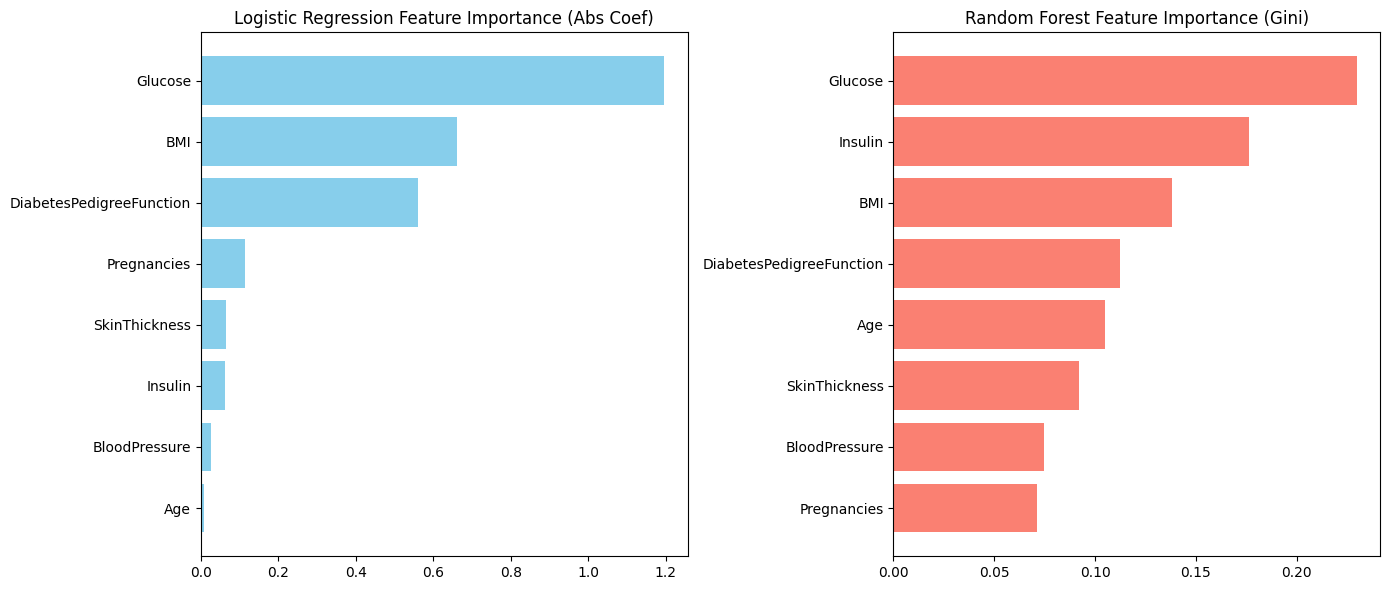

,Feature,Importance
1,Glucose,1.196274
5,BMI,0.661449
6,DiabetesPedigreeFunction,0.561147
0,Pregnancies,0.113501
3,SkinThickness,0.065626
4,Insulin,0.062976
2,BloodPressure,0.027029
7,Age,0.007174


,Feature,Importance
1,Glucose,0.229872
4,Insulin,0.176621
5,BMI,0.137931
6,DiabetesPedigreeFunction,0.112452
7,Age,0.104976
3,SkinThickness,0.091927
2,BloodPressure,0.074819
0,Pregnancies,0.071402


In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Logistic Regression 특성 중요도
# 선형 모델에서는 회귀 계수의 절대값이 클수록 영향력이 큼
lg_importance = np.abs(best_lg_model.coef_[0])
lg_features = pd.DataFrame({'Feature': X_train_imputed.columns, 'Importance': lg_importance})
lg_features = lg_features.sort_values(by='Importance', ascending=False)

# Random Forest 특성 중요도 : 지니계수
rf_importance = best_rf_model.feature_importances_
rf_features = pd.DataFrame({'Feature': X_train_imputed.columns, 'Importance': rf_importance})
rf_features = rf_features.sort_values(by='Importance', ascending=False)

# 시각화
plt.figure(figsize=(14, 6))

# Logistic Regression Plot
plt.subplot(1, 2, 1)
plt.barh(lg_features['Feature'], lg_features['Importance'], color='skyblue')
plt.title('Logistic Regression Feature Importance (Abs Coef)')
plt.gca().invert_yaxis()

# Random Forest Plot
plt.subplot(1, 2, 2)
plt.barh(rf_features['Feature'], rf_features['Importance'], color='salmon')
plt.title('Random Forest Feature Importance (Gini)')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

display(lg_features)
display(rf_features)

In [77]:
def apply_feature_engineering(df_in):
    df = df_in.copy()

    df['Age_Glucose'] = df['Age'] * df['Glucose']

    df['BMI_Glucose_Ratio'] = df['BMI'] / (df['Glucose'] + 1)

    df['Pregnancy_Freq'] = df['Pregnancies'] / (df['Age'] - 12)

    return df

X_train_fe = apply_feature_engineering(X_train_imputed)
X_test_fe = apply_feature_engineering(X_test_imputed)

# Retrain Logistic Regression
final_lg = LogisticRegression(max_iter=1000, C=1, solver='liblinear', random_state=42)
final_lg.fit(X_train_fe, y_train_copy)

fe_score = final_lg.score(X_test_fe, y_test)
print("LogisticRegression Test set : ", fe_score)

final_rf = RandomForestClassifier(
    bootstrap=True,
    max_depth=40,
    min_samples_leaf=1,
    min_samples_split=8,
    n_estimators=108,
    random_state=42
)

# Retrain RandomForestClassifier
final_rf.fit(X_train_fe, y_train_copy)

fe_rf_score = final_rf.score(X_test_fe, y_test)
print("RandomForestClassifier Test set : ", fe_rf_score)

LogisticRegression Test set :  0.7012987012987013
RandomForestClassifier Test set :  0.6948051948051948


In [78]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# K Fold setting
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("--- Train set 교차검증 (Featuring 후) ---")

# 1. Logistic Regression CV
lg_fe_cv_scores = cross_val_score(final_lg, X_train_fe, y_train_copy, cv=kfold, scoring='accuracy')
print("\n[Logistic Regression]")
print(f"CV Scores: {lg_fe_cv_scores}")
print(f"Best CV Score (Mean): {lg_fe_cv_scores.mean():.4f}")

# 2. Random Forest CV
rf_fe_cv_scores = cross_val_score(final_rf, X_train_fe, y_train_copy, cv=kfold, scoring='accuracy')
print("\n[Random Forest]")
print(f"CV Scores: {rf_fe_cv_scores}")
print(f"Best CV Score (Mean): {rf_fe_cv_scores.mean():.4f}")

--- Train set 교차검증 (Featuring 후) ---

[Logistic Regression]
CV Scores: [0.80487805 0.78861789 0.80487805 0.78861789 0.7704918 ]
Best CV Score (Mean): 0.7915

[Random Forest]
CV Scores: [0.79674797 0.76422764 0.81300813 0.74796748 0.78688525]
Best CV Score (Mean): 0.7818


In [79]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

lg_rand_grid_fe = {
    'C': uniform(0.01, 100),
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

# RandomizedSearchCV
lg_random_search_fe = RandomizedSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_distributions=lg_rand_grid_fe,
    n_iter=50,
    cv=kfold,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

lg_random_search_fe.fit(X_train_fe, y_train_copy)

print("Logistic Regression Random Search (Feature Engineering)")
print("Best Parameters: " , lg_random_search_fe.best_params_)
print("Best CV Score: ", lg_random_search_fe.best_score_)

best_lg_fe = lg_random_search_fe.best_estimator_
test_acc_fe = best_lg_fe.score(X_test_fe, y_test)
print("Logistic Regression Random Search Test set : ", test_acc_fe)

rf_rand_grid_fe = {
    'n_estimators': randint(100, 500),
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'bootstrap': [True, False]
}

# Initialize RandomizedSearchCV
rf_random_search_fe = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_rand_grid_fe,
    n_iter=20,
    cv=kfold,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

rf_random_search_fe.fit(X_train_fe, y_train_copy)

print("Random Forest Random Search (Feature Engineering)")
print("Best RF Parameters: " , rf_random_search_fe.best_params_)
print("Best RF CV Score: " , rf_random_search_fe.best_score_)


best_rf_fe = rf_random_search_fe.best_estimator_
rf_test_acc_fe = best_rf_fe.score(X_test_fe, y_test)
print("Random Forest Random Search Test set : ", rf_test_acc_fe)

Logistic Regression Random Search (Feature Engineering)
Best Parameters:  {'C': np.float64(5.818361216819946), 'penalty': 'l2', 'solver': 'liblinear'}
Best CV Score:  0.7914967346394775
Logistic Regression Random Search Test set :  0.7012987012987013
Random Forest Random Search (Feature Engineering)
Best RF Parameters:  {'bootstrap': True, 'max_depth': 40, 'min_samples_leaf': 9, 'min_samples_split': 8, 'n_estimators': 373}
Best RF CV Score:  0.7866586698653871
Random Forest Random Search Test set :  0.7207792207792207


In [89]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

y_pred_rf_rs = best_rf_fe.predict(X_test_fe)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred_rf_rs):.4f}")

print("classification_report")
print(classification_report(y_test, y_pred_rf_rs))

print("Confusion Matrix")
cm_rf_rs = confusion_matrix(y_test, y_pred_rf_rs)
display(pd.DataFrame(cm_rf_rs, index=['Actual 0', 'Actual 1'], columns=['Predict 0', 'Predict 1']))

Test Accuracy: 0.7208
classification_report
              precision    recall  f1-score   support

           0       0.77      0.82      0.79       100
           1       0.62      0.54      0.57        54

    accuracy                           0.72       154
   macro avg       0.69      0.68      0.68       154
weighted avg       0.71      0.72      0.72       154

Confusion Matrix


,Predict 0,Predict 1
Actual 0,82,18
Actual 1,25,29


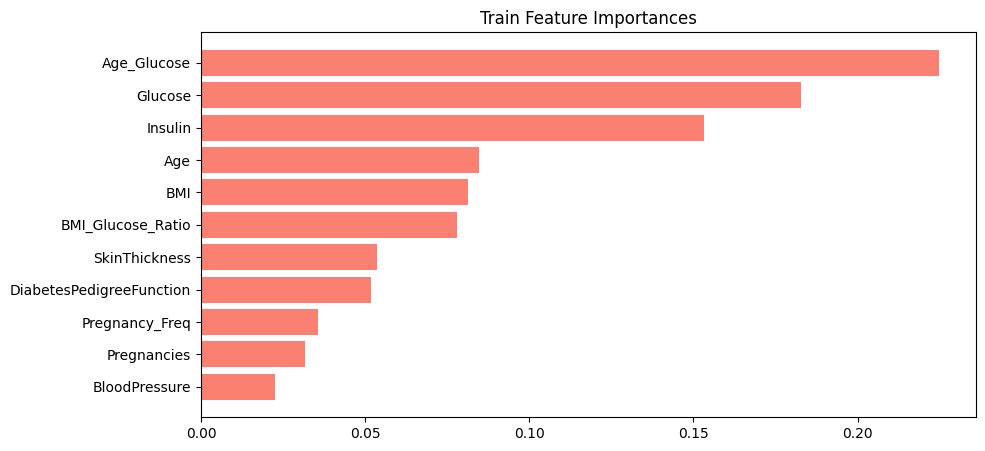

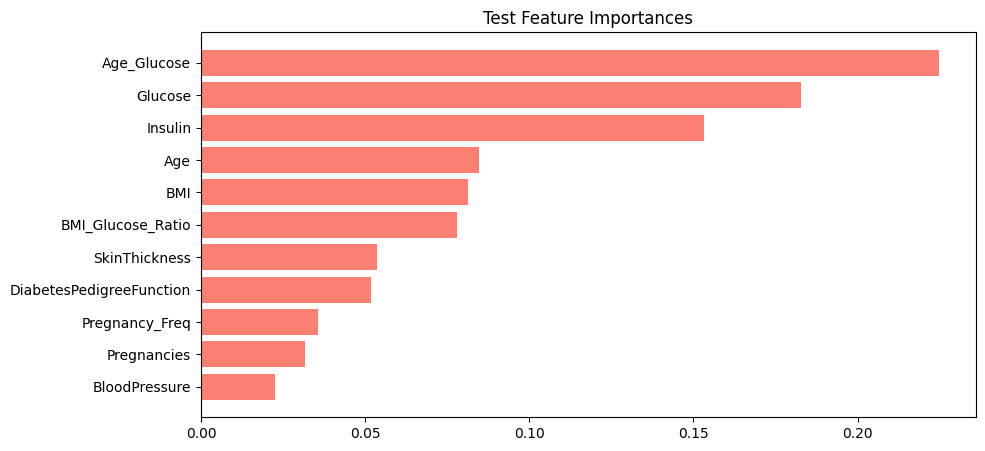

In [101]:
import pandas as pd
import matplotlib.pyplot as plt

# train 특성 중요도
importances = best_rf_fe.feature_importances_
feature_names = X_train_fe.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# 시각화
plt.figure(figsize=(10, 5))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='salmon')
plt.gca().invert_yaxis()
plt.title('Train Feature Importances')
plt.show()

# test 특성 중요도
importances = best_rf_fe.feature_importances_
feature_names = X_test_fe.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# 시각화
plt.figure(figsize=(10, 5))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='salmon')
plt.gca().invert_yaxis()
plt.title('Test Feature Importances')
plt.show()

In [ ]:
# import pandas as pd
# from sklearn.model_selection import GridSearchCV
# from imblearn.over_sampling import SMOTE
# from sklearn.metrics import classification_report, confusion_matrix

# #하위 2개 변수만 제거
# low_impact_2 = ['SkinThickness', 'BloodPressure']
# X_train_refined = X_train_imputed.drop(columns=low_impact_2)
# X_test_refined = X_test_imputed.drop(columns=low_impact_2)

# print(f'제거된 변수: {low_impact_2}')
# print(f'남은 변수: {X_train_refined.columns.tolist()}')

# param_grid_refined = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [None, 10, 20],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'bootstrap': [True]
# }

# grid_refined = GridSearchCV(
#     RandomForestClassifier(random_state=42),
#     param_grid_refined,
#     cv=kfold,
#     scoring='accuracy',
#     n_jobs=-1
# )
# grid_refined.fit(X_train_refined, y_train_copy)

# best_params = grid_refined.best_params_
# print(f'\nBest Parameters: {best_params}')

# # SMOTE : 데이터가 적은 부분을 가상으로 생성
# smote_refined = SMOTE(random_state=42)
# X_train_res_ref, y_train_res_ref = smote_refined.fit_resample(X_train_refined, y_train_copy)

# # 재학습
# final_model_refined = RandomForestClassifier(**best_params, random_state=42)
# final_model_refined.fit(X_train_res_ref, y_train_res_ref)

# # 성능 평가
# y_pred_ref = final_model_refined.predict(X_test_refined)
# test_acc_ref = final_model_refined.score(X_test_refined, y_test)

# print(f'변수 제거 후 남은 6개의 특징들로 학습한 결과의 정확도')
# print(f'Test Accuracy: {test_acc_ref:.4f}')
# print('\n[Classification Report]')
# print(classification_report(y_test, y_pred_ref))

# print('\n[Confusion Matrix]')
# print(confusion_matrix(y_test, y_pred_ref))

# #정확도는 떨어졌으나 Recall(재현율)은 상승 - 당뇨병 진단 예측도 상승(65% -> 70%)

제거된 변수: ['SkinThickness', 'BloodPressure']
남은 변수: ['Pregnancies', 'Glucose', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


목표 재현율: 0.9074
최적 임계값: 0.2578


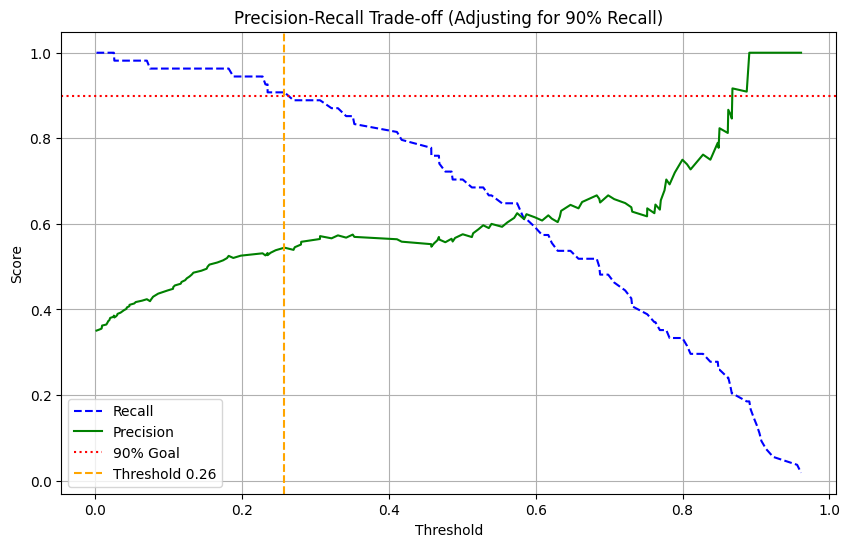

In [83]:
# from sklearn.metrics import precision_recall_curve
# import matplotlib.pyplot as plt

# #SMOTE를 통해 refine된 테스트 데이터 예측 및 재현율, 정밀도 계산하기
# y_scores = final_model_refined.predict_proba(X_test_refined)[:, 1]
# precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

# # 재현율 90% 이상
# target_recall = 0.90
# idx = np.where(recalls >= target_recall)[0][-1]
# optimal_threshold = thresholds[idx]

# print(f'목표 재현율: {recalls[idx]:.4f}')
# print(f'최적 임계값: {optimal_threshold:.4f}')

# # 시각화
# plt.figure(figsize=(10, 6))
# plt.plot(thresholds, recalls[:-1], 'b--', label='Recall')
# plt.plot(thresholds, precisions[:-1], 'g-', label='Precision')
# plt.axhline(y=0.9, color='r', linestyle=':', label='90% Goal')
# plt.axvline(x=optimal_threshold, color='orange', linestyle='--', label=f'Threshold {optimal_threshold:.2f}')
# plt.xlabel('Threshold')
# plt.ylabel('Score')
# plt.title('Precision-Recall Trade-off (Adjusting for 90% Recall)')
# plt.legend()
# plt.grid(True)
# plt.show()

In [84]:
# from sklearn.metrics import classification_report, confusion_matrix

# # optimal_threshold 임계값 적용 후 재예측
# custom_threshold = optimal_threshold
# y_pred_90 = (y_scores >= custom_threshold).astype(int)

# print(custom_threshold)
# print(classification_report(y_test, y_pred_90))

# #confusion_matrix 확인
# cm = confusion_matrix(y_test, y_pred_90)
# display(pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Predict 0', 'Predict 1']))

0.2578306032552094
              precision    recall  f1-score   support

           0       0.92      0.59      0.72       100
           1       0.54      0.91      0.68        54

    accuracy                           0.70       154
   macro avg       0.73      0.75      0.70       154
weighted avg       0.79      0.70      0.71       154



,Predict 0,Predict 1
Actual 0,59,41
Actual 1,5,49


In [85]:
# from sklearn.metrics import classification_report, confusion_matrix

# # 최종 모델로부터 테스트 데이터에 대한 확률값 추출
# y_probs_final = final_model_refined.predict_proba(X_test_refined)[:, 1]

# # 90% 이상의 재현율을 가진 구간만 필터링
# mask = recalls >= 0.90
# valid_precisions = precisions[mask]
# valid_thresholds = thresholds[mask[:-1]]

# best_idx = np.argmax(valid_precisions)
# final_optimal_threshold = valid_thresholds[best_idx]
# final_recall = recalls[mask][best_idx]
# final_precision = valid_precisions[best_idx]

# print(f'최적 임계값: {final_optimal_threshold:.4f}')
# print(f'최종 재현율: {final_recall:.4f}')
# print(f'최종 정밀도: {final_precision:.4f}')

# y_pred_final = (y_probs_final >= final_optimal_threshold).astype(int)
# print(classification_report(y_test, y_pred_final))

# cm_final_fine = confusion_matrix(y_test, y_pred_final)
# display(pd.DataFrame(cm_final_fine, index=['Actual 0', 'Actual 1'], columns=['Predict 0', 'Predict 1']))

최적 임계값: 0.2578
최종 재현율: 0.9074
최종 정밀도: 0.5444
              precision    recall  f1-score   support

           0       0.92      0.59      0.72       100
           1       0.54      0.91      0.68        54

    accuracy                           0.70       154
   macro avg       0.73      0.75      0.70       154
weighted avg       0.79      0.70      0.71       154



,Predict 0,Predict 1
Actual 0,59,41
Actual 1,5,49


In [103]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# 현재 활성화된 데이터셋(X_train_fe, X_test_fe)에서 상위 4개 특성 선택
# Age_Glucose는 특성 공학으로 생성된 변수 중 중요도가 높으므로 이를 포함하거나,
# 원본 요청대로 간소화된 4개 특성을 사용합니다.
top_4_features = ['Glucose', 'Insulin', 'BMI', 'DiabetesPedigreeFunction']
X_train_top4 = X_train_fe[top_4_features]
X_test_top4 = X_test_fe[top_4_features]

# 모델 설정
final_model_top4 = RandomForestClassifier(
    bootstrap=True,
    max_depth=10,
    min_samples_leaf=4,
    min_samples_split=10,
    n_estimators=100,
    random_state=42
)

# 학습 (y_train_res_ref 대신 y_train_copy 사용)
final_model_top4.fit(X_train_top4, y_train_copy)

# 당뇨환자 예측함수 작성
def predict_diabetes_simple(glucose, insulin, bmi, diabetesPedigreeFunction, threshold=0.2578):
    new_data = pd.DataFrame([[glucose, insulin, bmi, diabetesPedigreeFunction]],
                            columns=['Glucose', 'Insulin', 'BMI', 'DiabetesPedigreeFunction'])

    prob = final_model_top4.predict_proba(new_data)[0][1]
    prediction = 1 if prob >= threshold else 0

    return {
        'Diagnosis': '양성(Positive)' if prediction == 1 else '음성(Negative)',
        'Probability': f"{prob:.4f}"
    }

# 샘플 환자 예측 테스트
sample_patient = X_test_top4.iloc[0]
result = predict_diabetes_simple(
    sample_patient['Glucose'],
    sample_patient['Insulin'],
    sample_patient['BMI'],
    sample_patient['DiabetesPedigreeFunction']
)

print("신규 환자 예측 결과")
for key, value in result.items():
    print(f"{key}: {value}")

신규 환자 예측 결과
Diagnosis: 양성(Positive)
Probability: 0.6036


In [ ]:
#SMOTE

In [106]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd

# 1. 테스트 데이터 예측 (top_4_features 사용)
y_pred_top4 = final_model_top4.predict(X_test_top4)

# 2. 정확도(Accuracy) 계산
accuracy = accuracy_score(y_test, y_pred_top4)
print(f"[Final Model Top4] Test Accuracy: {accuracy:.4f}")

# 3. Classification Report 출력
print("\n[Classification Report]")
print(classification_report(y_test, y_pred_top4))

# 4. Confusion Matrix 출력
print("[Confusion Matrix]")
cm_top4 = confusion_matrix(y_test, y_pred_top4)
cm_df = pd.DataFrame(cm_top4, index=['Actual 0', 'Actual 1'], columns=['Predict 0', 'Predict 1'])
display(cm_df)

[Final Model Top4] Test Accuracy: 0.6818

[Classification Report]
              precision    recall  f1-score   support

           0       0.73      0.81      0.77       100
           1       0.56      0.44      0.49        54

    accuracy                           0.68       154
   macro avg       0.64      0.63      0.63       154
weighted avg       0.67      0.68      0.67       154

[Confusion Matrix]


,Predict 0,Predict 1
Actual 0,81,19
Actual 1,30,24


In [104]:
# 샘플 데이터 작성
test_glucose = 133
test_insulin = 140
test_bmi = 33
test_diabetesPedigreeFunction = 2.6

# Glucose에 대해 공복혈당/식후혈당으로 나눠서 측정된 데이터가 있다면 더 정확했을듯
# 나이 요소만 45세에서 22세로 낮추고 나머지는 실제 당뇨환자 데이터로 넣었는데 당뇨가 음성이됨.
# 나이 요소를 특성에서 제거
# 다른 요소는 다 그대로 놔두고 BMI만 비만이 아닌 상태로 낮추니 실제로도 공복혈당장애에 해당되는데 이는 당뇨는 음성이긴함
# 좀 더 정확한 예측을 위해 Glucose를 공복혈당/식후혈당으로 나눠서 raw data 수집하면 더 좋을듯

input_for_scaler = pd.DataFrame([[test_glucose, 70, 20, test_insulin, test_bmi]],
                                columns=['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI'])

#스케일링
scaled_values = scaler.transform(input_for_scaler)[0]

#스케일링된 특성 추출
s_glucose = scaled_values[0]
s_insulin = scaled_values[3]
s_bmi = scaled_values[4]

# 환자 예측 함수 호출
custom_result = predict_diabetes_simple(s_glucose, s_insulin, s_bmi, test_diabetesPedigreeFunction)

print(f"입력 데이터 - Glucose: {test_glucose}, Insulin: {test_insulin}, BMI: {test_bmi}, DPF: {test_diabetesPedigreeFunction}")
print("예측 결과")
for key, value in custom_result.items():
    print(f"{key}: {value}")

입력 데이터 - Glucose: 133, Insulin: 140, BMI: 33, DPF: 2.6
예측 결과
Diagnosis: 양성(Positive)
Probability: 0.6605


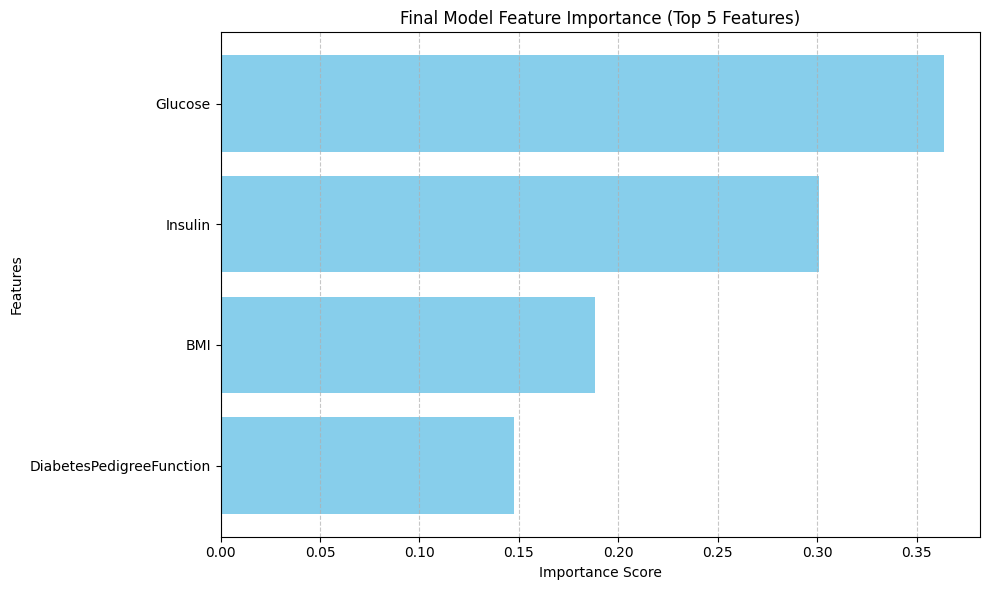

,Feature,Importance
0,Glucose,0.363693
1,Insulin,0.300841
2,BMI,0.188046
3,DiabetesPedigreeFunction,0.147420


In [105]:
import pandas as pd
import matplotlib.pyplot as plt

# 특성 정확도
importances = final_model_top4.feature_importances_

# 간소화된 4개 특성
feature_names = ['Glucose', 'Insulin', 'BMI', 'DiabetesPedigreeFunction']

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Final Model Feature Importance (Top 5 Features)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

display(fi_df.sort_values(by='Importance', ascending=False))